# SPCA comparison: Bair vs manifold optimization

This notebook compares two supervised PCA approaches on the Parkinsons telemonitoring dataset:
- **Bair's method** with the best parameter found in `spca_bair.ipynb` (`theta=2.2`),
- **Manifold optimization SPCA** with `lambda=0.01` (as selected in `spca.ipynb`).

We compare them using:
- **Variance explained** (higher is better),
- **Prediction error** (lower is better).

In [10]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from models import SupervisedPCA
from models.spca_bair import SPCA_Bair
from utils import load_parkinsons_data, normalize_to_minus1_1, variation_explained, prediction_error

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same preprocessing as in spca.ipynb
X, y, feature_names = load_parkinsons_data(device)
X = X - X.mean(dim=0)
y = y - y.mean(dim=0)
X = normalize_to_minus1_1(X)
y = normalize_to_minus1_1(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1000, 19])
y shape: torch.Size([1000, 1])


In [12]:
# Chosen parameters from other notebooks
k = 2
best_theta_bair = 2.2
best_lambda_manifold = 0.01

In [13]:
# Fit Bair SPCA
X_np = X.detach().cpu().numpy()
y_np = y.squeeze(-1).detach().cpu().numpy()

bair_model = SPCA_Bair(theta=best_theta_bair, n_components=k)
bair_model.fit(X_np, y_np)

# Build a full loading matrix L_bair with shape (p, k)
# so we can evaluate with the same utility functions.
L_bair = torch.zeros((X.shape[1], k), dtype=X.dtype, device=X.device)
L_bair[bair_model.selected_idx, :] = torch.tensor(bair_model.w.T, dtype=X.dtype, device=X.device)

print("Bair selected features:", len(bair_model.selected_idx))

Bair selected features: 5


In [14]:
# Fit manifold-optimization SPCA
manifold_model = SupervisedPCA(input_dim=X.shape[1], output_dim=k)
manifold_model.train(X, y, lam=best_lambda_manifold, steps=200)
L_manifold = manifold_model.L.detach()

Step 0: loss = 332.4944
Step 10: loss = 239.1380
Step 20: loss = 236.4748
Step 30: loss = 234.7331
Step 40: loss = 232.0722
Step 50: loss = 230.9810
Step 60: loss = 230.6495
Step 70: loss = 230.4262
Step 80: loss = 230.2139
Step 90: loss = 230.0437
Step 100: loss = 229.9047
Step 110: loss = 229.7717
Step 120: loss = 229.6475
Step 130: loss = 229.5535
Step 140: loss = 229.4649
Step 150: loss = 229.3789
Step 160: loss = 229.2997
Step 170: loss = 229.2382
Step 180: loss = 229.1600
Step 190: loss = 229.1015


In [15]:
# Evaluate both methods with the same metrics
metrics = {
    "Bair SPCA": {
        "Variance explained": variation_explained(X, L_bair).item(),
        "Prediction error": prediction_error(X, L_bair, y).item(),
    },
    "Manifold SPCA": {
        "Variance explained": variation_explained(X, L_manifold).item(),
        "Prediction error": prediction_error(X, L_manifold, y).item(),
    },
}

df = pd.DataFrame(metrics).T
df

,Variance explained,Prediction error
Bair SPCA,0.116972,0.308333
Manifold SPCA,0.827109,0.213220


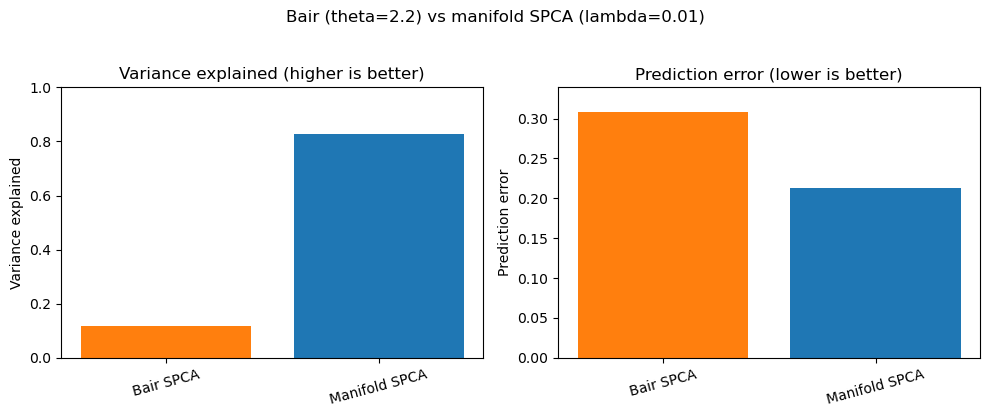

In [16]:
# Visual comparison of the two metrics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Variance explained (higher is better)
axes[0].bar(df.index, df["Variance explained"], color=["tab:orange", "tab:blue"])
axes[0].set_ylabel("Variance explained")
axes[0].set_title("Variance explained (higher is better)")
axes[0].set_ylim(0, max(1.0, df["Variance explained"].max() * 1.1))

# Prediction error (lower is better)
axes[1].bar(df.index, df["Prediction error"], color=["tab:orange", "tab:blue"])
axes[1].set_ylabel("Prediction error")
axes[1].set_title("Prediction error (lower is better)")
axes[1].set_ylim(0, df["Prediction error"].max() * 1.1)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

fig.suptitle(
    f"Bair (theta={best_theta_bair}) vs manifold SPCA (lambda={best_lambda_manifold})",
    y=1.03,
)
plt.tight_layout()
plt.show()

## Results summary

Using the selected parameters (`theta=2.2` for Bair, `lambda=0.01` for manifold SPCA), the manifold method performs better on both evaluation metrics:

- **Variance explained**:
  - Bair SPCA: **0.117**
  - Manifold SPCA: **0.827**
- **Prediction error** (lower is better):
  - Bair SPCA: **0.308**
  - Manifold SPCA: **0.213**

This means the manifold optimization approach both preserves substantially more structure from `X` and provides better target prediction in this setup. Bair's method is much more aggressive in feature filtering (5 selected features), which likely contributes to its lower explained variance.

### Loadings comparison

In [17]:
def top_loading_table(A, B, names, comp_idx, top_k=5):
    """
    A, B: loading matrices of shape (p, k)
    names: list of feature names
    comp_idx: component index (0-based)
    """
    a = A[:, comp_idx]
    b = B[:, comp_idx]

    order_a = np.argsort(np.abs(a))[::-1][:top_k]
    order_b = np.argsort(np.abs(b))[::-1][:top_k]

    df_comp = pd.DataFrame(
        {
            ("Bair SPCA", "Feature"): [names[i] for i in order_a],
            ("Bair SPCA", "Loading"): [f"{a[i]:+.4f}" for i in order_a],
            ("Manifold SPCA", "Feature"): [names[i] for i in order_b],
            ("Manifold SPCA", "Loading"): [f"{b[i]:+.4f}" for i in order_b],
        },
        index=pd.Index(range(1, top_k + 1), name="Rank"),
    )
    return df_comp

A = L_bair.detach().cpu().numpy()      # (p, k)
B = L_manifold.detach().cpu().numpy()  # (p, k)
names = feature_names

for j in range(k):
    print(f"\nComponent {j + 1}")
    display(top_loading_table(A, B, names, comp_idx=j, top_k=5))


Component 1


Bair SPCA          Manifold SPCA         
        Feature  Loading       Feature  Loading
Rank                                           
1           age  -0.9511   Jitter:PPQ5  -0.4328
2           DFA  +0.2898   Jitter(Abs)  -0.4247
3          RPDE  -0.0808       Shimmer  -0.3139
4     test_time  +0.0519   Shimmer(dB)  -0.2935
5           HNR  +0.0469  Shimmer:APQ5  +0.2797


Component 2


Bair SPCA           Manifold SPCA         
        Feature  Loading        Feature  Loading
Rank                                            
1           DFA  -0.7096   Shimmer:APQ5  -0.4299
2          RPDE  -0.4528     Jitter:RAP  -0.3853
3     test_time  -0.3613     Jitter:DDP  -0.3853
4           HNR  +0.3586            sex  -0.3226
5           age  -0.1798  Shimmer:APQ11  -0.3066